In [1]:
!pip install xlrd

In [2]:
# ============================================
# Retail Sales Analysis Project
# Step 2 — Import Libraries
# ============================================

# pandas → Data manipulation
# DataCamp: Data Manipulation with pandas
import pandas as pd

# numpy → numerical operations
import numpy as np

# matplotlib → basic visualization
import matplotlib.pyplot as plt

# seaborn → statistical visualization
import seaborn as sns

# Optional: set visualization style
# This only changes how charts look
# DataCamp: Seaborn styling
sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# ============================================
# Step 3 — Load Dataset
# ============================================

# DataCamp Mapping:
# Introduction to Importing Data in Python

# Load dataset
df = pd.read_excel("../data/raw/retail_sales.xls")

df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870


In [4]:
# Check number of rows and columns
df.shape

(10194, 21)

In [5]:
# View column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [6]:
# Check datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

In [7]:
# Summary Statistics
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [8]:
# Check Missing Values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [9]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Check Date Columns
# Check first few rows
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,2023-01-03,2023-01-07
1,2023-01-04,2023-01-08
2,2023-01-04,2023-01-08
3,2023-01-04,2023-01-08
4,2023-01-05,2023-01-12


In [11]:
# Extract Year
df['Order Year'] = df['Order Date'].dt.year
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023


In [12]:
# Extract Month
df['Order Month'] = df['Order Date'].dt.month
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1


In [13]:
# Extract Day of Week
df['Order Day'] = df['Order Date'].dt.day_name()
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,Tuesday
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,Wednesday


In [14]:
# Sales by Year
sales_by_year = df.groupby('Order Year')['Sales'].sum()

sales_by_year

Order Year
2023    494040.2121
2024    472993.0310
2025    613933.5800
2026    745567.5312
Name: Sales, dtype: float64

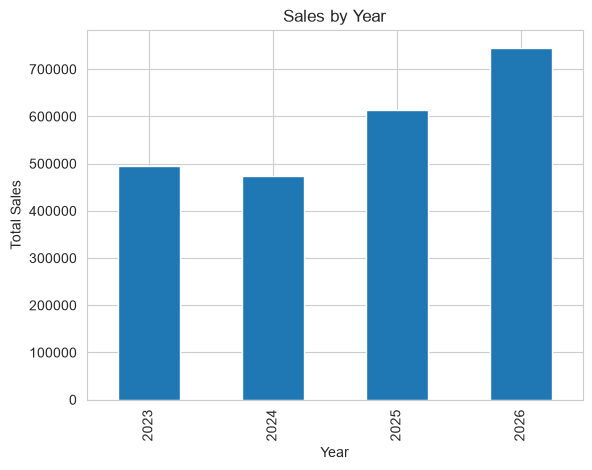

In [15]:
# Plot Sales by Year
sales_by_year.plot(kind='bar')

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [16]:
# Sales by Month

sales_by_month = df.groupby('Order Month')['Sales'].sum()

sales_by_month

Order Month
1      96069.5156
2      59751.2514
3     210672.0868
4     138098.7486
5     158765.0337
6     153459.9973
7     149001.7130
8     161821.9150
9     308883.6697
10    207126.2567
11    352665.9910
12    330218.1755
Name: Sales, dtype: float64

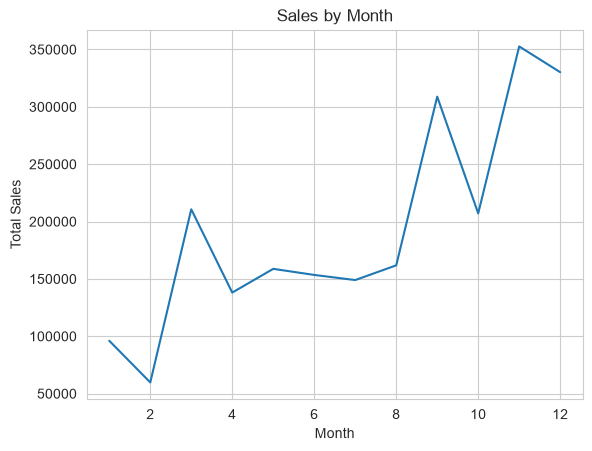

In [17]:
# Plot Monthly Sales

sales_by_month.plot(kind = 'line')

plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

In [18]:
# Sales by Category
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_by_category

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64

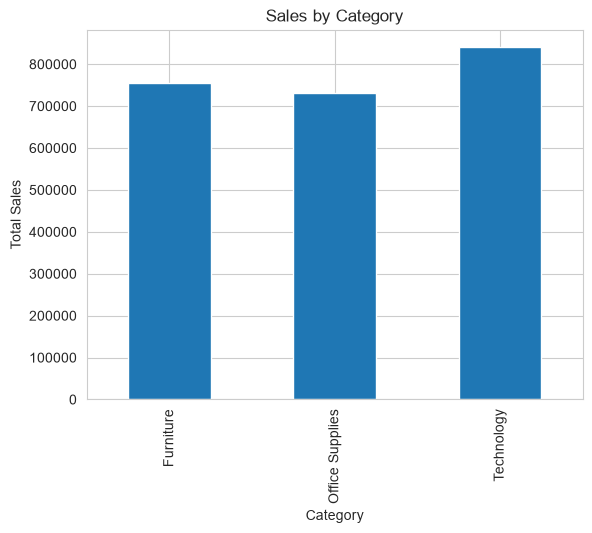

In [19]:
# Plot Category Sales

sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [20]:
# Profit by Category

profit_by_category = df.groupby('Category')['Profit'].sum()

profit_by_category

Category
Furniture           19729.9956
Office Supplies    126023.4434
Technology         146543.3756
Name: Profit, dtype: float64

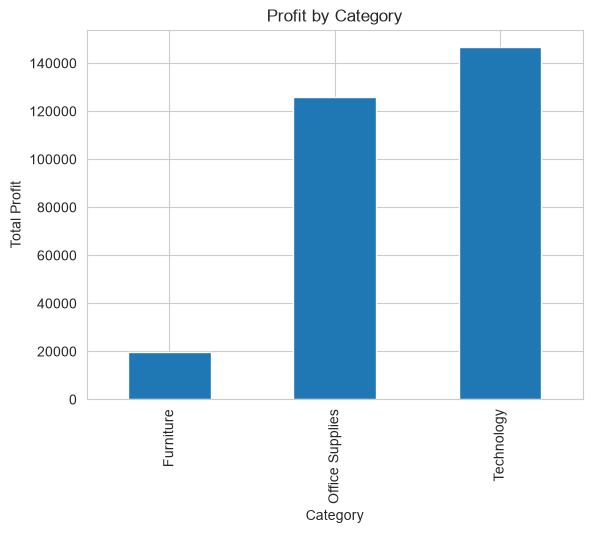

In [21]:
# Plot Profit by Category

profit_by_category.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

In [22]:
# Profit by Sub-Category

profit_by_subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values()

profit_by_subcategory

Sub-Category
Tables        -17753.2061
Bookcases      -3632.0736
Supplies       -1171.3945
Fasteners       2428.6358
Machines        3461.9769
Labels          5572.7780
Art             6653.1962
Envelopes       6988.0247
Furnishings    13891.7430
Appliances     18329.4844
Storage        21285.1115
Chairs         27223.5323
Binders        31426.1003
Paper          34511.5070
Accessories    41936.6357
Phones         45050.8265
Copiers        56093.9365
Name: Profit, dtype: float64

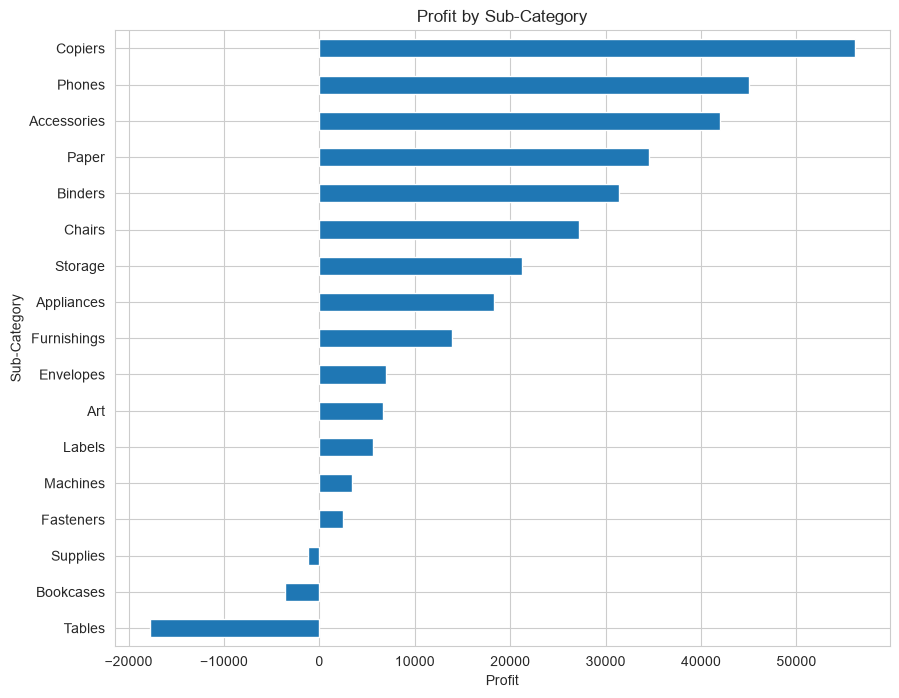

In [23]:
# Plot Sub-Category Profit

profit_by_subcategory.plot(kind='barh' , figsize=(10,8))

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

In [24]:
profit_by_category

Category
Furniture           19729.9956
Office Supplies    126023.4434
Technology         146543.3756
Name: Profit, dtype: float64

In [25]:
profit_by_subcategory

Sub-Category
Tables        -17753.2061
Bookcases      -3632.0736
Supplies       -1171.3945
Fasteners       2428.6358
Machines        3461.9769
Labels          5572.7780
Art             6653.1962
Envelopes       6988.0247
Furnishings    13891.7430
Appliances     18329.4844
Storage        21285.1115
Chairs         27223.5323
Binders        31426.1003
Paper          34511.5070
Accessories    41936.6357
Phones         45050.8265
Copiers        56093.9365
Name: Profit, dtype: float64

In [26]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,Tuesday
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,Wednesday


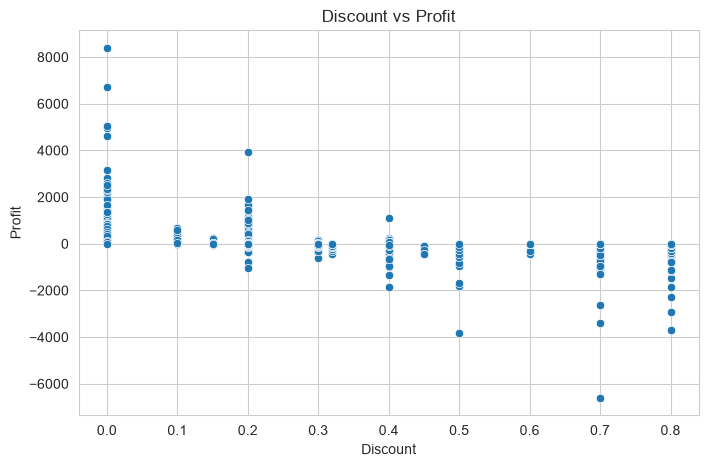

In [27]:
# Scatter Plot (Discount vs Profit)

plt.figure(figsize=(8,5))

sns.scatterplot(x='Discount', y='Profit', data=df)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [28]:
# Top Products Analysis

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

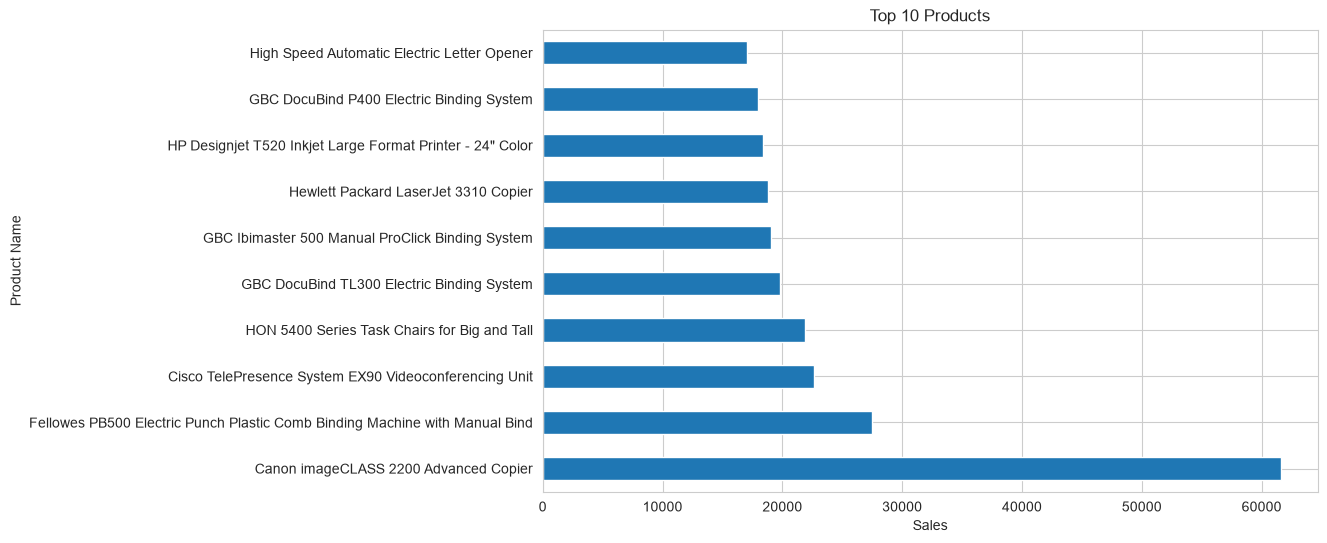

In [29]:
# Plot Top Products

top_products.plot(kind='barh', figsize=(10, 6))

plt.title("Top 10 Products")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.show()

In [30]:
# Sales by Region

sales_by_region = df.groupby('Region')['Sales'].sum()

sales_by_region

Region
Central    503170.6728
East       691828.1680
South      391721.9050
West       739813.6085
Name: Sales, dtype: float64

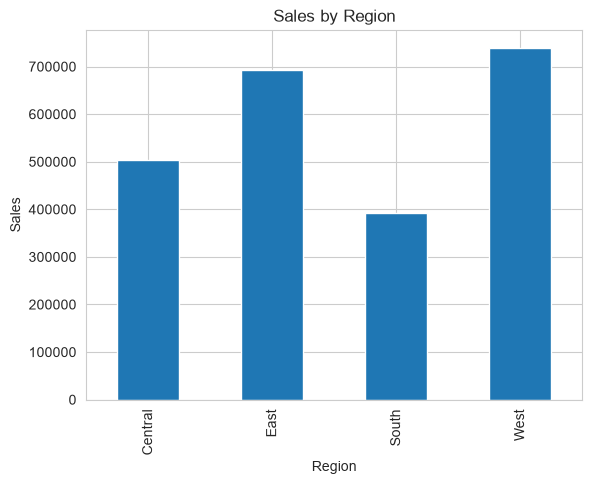

In [31]:
sales_by_region.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [32]:
# Profit by Region

profit_by_region = df.groupby('Region')['Profit'].sum()

profit_by_region

Region
Central     39865.3070
East        94883.2603
South       46749.4303
West       110798.8170
Name: Profit, dtype: float64

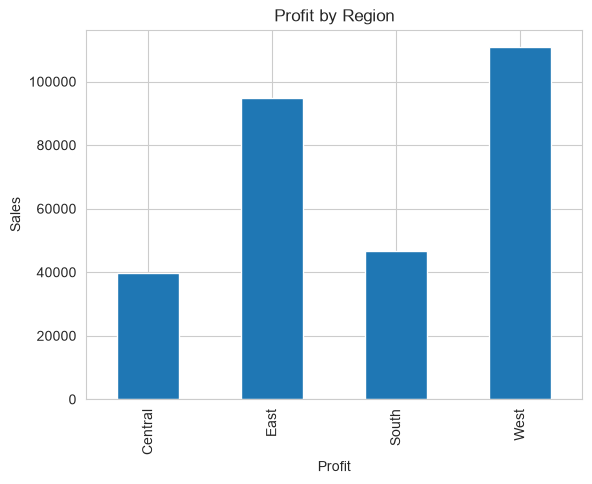

In [33]:
profit_by_region.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Profit")
plt.ylabel("Sales")

plt.show()

In [34]:
# Sales by Segment

sales_by_segment = df.groupby('Segment')['Sales'].sum()

sales_by_segment

Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64

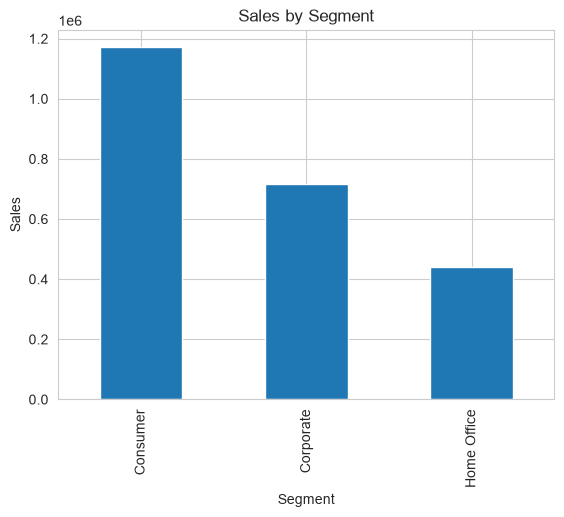

In [35]:
sales_by_segment.plot(kind='bar')

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

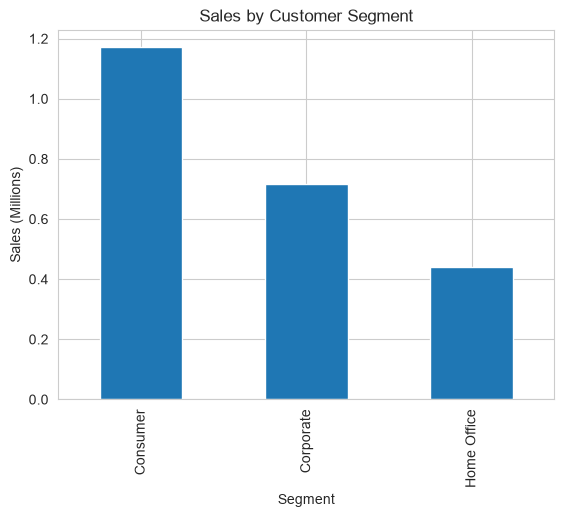

In [36]:
# make it look nicer for business users:
sales_by_segment_millions = sales_by_segment / 1_000_000

sales_by_segment_millions.plot(kind='bar')

plt.ylabel("Sales (Millions)")
plt.title("Sales by Customer Segment")

plt.show()

In [37]:
# ============================================
# Step 13.3 — Profit by Segment
# ============================================

profit_by_segment = df.groupby('Segment')['Profit'].sum()

profit_by_segment

Segment
Consumer       136371.4463
Corporate       94249.6400
Home Office     61675.7283
Name: Profit, dtype: float64

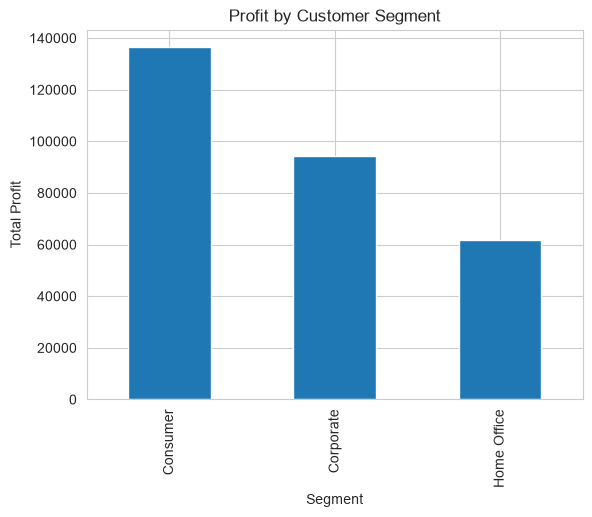

In [38]:
profit_by_segment.plot(kind='bar')

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")

plt.show()

In [39]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,Tuesday
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,Wednesday


In [40]:
top_customers_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_sales

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

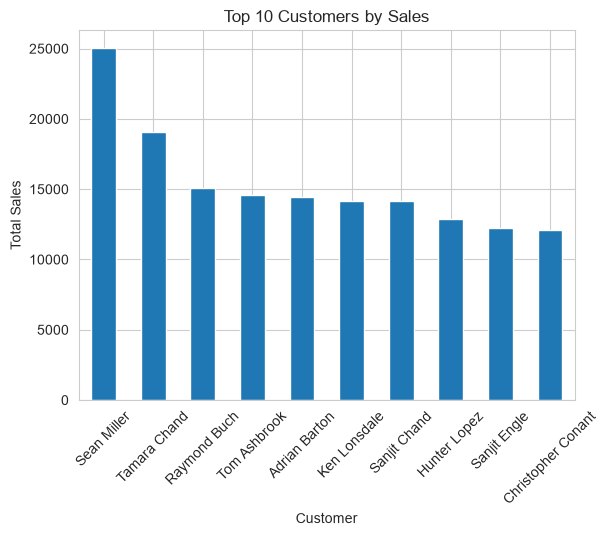

In [41]:
top_customers_sales.plot(kind='bar')

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()


In [42]:
top_customers_profit = (
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_profit

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

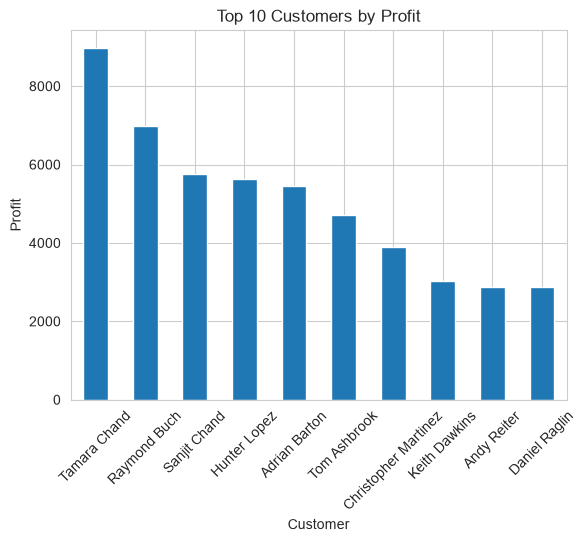

In [43]:
top_customers_profit.plot(kind='bar')

plt.title("Top 10 Customers by Profit")
plt.xlabel("Customer")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.show()

In [44]:
# Step 15.1 — Sales by Region

sales_by_region = df.groupby('Region')['Sales'].sum()

sales_by_region

Region
Central    503170.6728
East       691828.1680
South      391721.9050
West       739813.6085
Name: Sales, dtype: float64

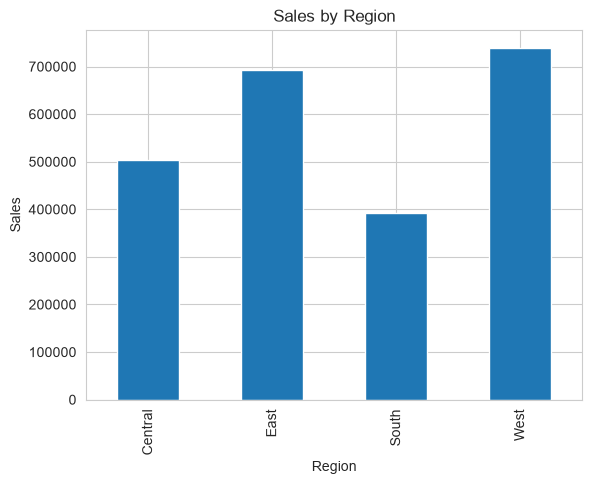

In [45]:
sales_by_region.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [46]:
# Step 15.3 — Profit by Region

profit_by_region = df.groupby('Region')['Profit'].sum()

profit_by_region

Region
Central     39865.3070
East        94883.2603
South       46749.4303
West       110798.8170
Name: Profit, dtype: float64

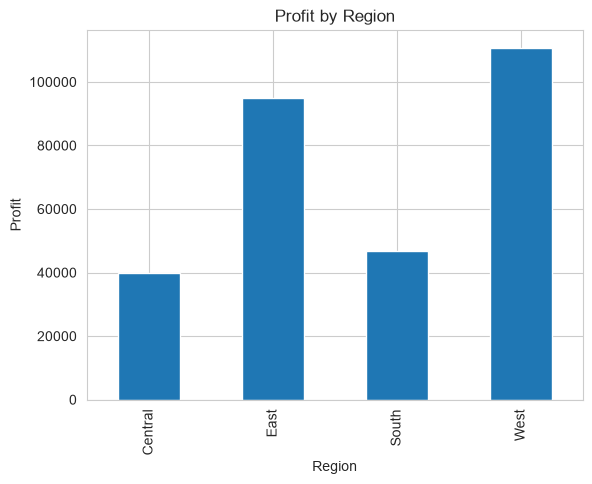

In [47]:
profit_by_region.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [48]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Order Year', 'Order Month', 'Order Day'],
      dtype='str')

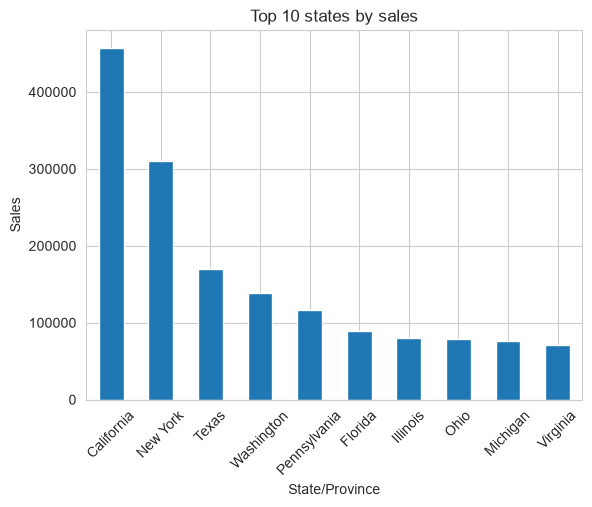

In [49]:
# Top 10 states by sales
top_10_states=df.groupby('State/Province')['Sales'].sum().sort_values(ascending=False).head(10)

top_10_states.plot(kind='bar')

plt.title("Top 10 states by sales")
plt.xlabel("State/Province")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.show()

In [50]:
sales_by_category

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64

In [51]:
# ============================================
# Step 16.3 — Sub-Category Analysis
# ============================================

subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

print("Top Sub-Categories by Sales:\n", subcat_sales.head(10))
print("\nTop Sub-Categories by Profit:\n", subcat_profit.head(10))

Top Sub-Categories by Sales:
 Sub-Category
Chairs         335768.2490
Phones         331842.6400
Storage        224644.5540
Tables         208020.1820
Binders        207354.8810
Machines       189925.0310
Accessories    167380.3180
Copiers        150745.2900
Bookcases      115361.2043
Appliances     108213.1850
Name: Sales, dtype: float64

Top Sub-Categories by Profit:
 Sub-Category
Copiers        56093.9365
Phones         45050.8265
Accessories    41936.6357
Paper          34511.5070
Binders        31426.1003
Chairs         27223.5323
Storage        21285.1115
Appliances     18329.4844
Furnishings    13891.7430
Envelopes       6988.0247
Name: Profit, dtype: float64


In [52]:
loss_subcats = subcat_profit[subcat_profit < 0]

print("Loss-Making Sub-Categories:\n", loss_subcats)

Loss-Making Sub-Categories:
 Sub-Category
Supplies     -1171.3945
Bookcases    -3632.0736
Tables      -17753.2061
Name: Profit, dtype: float64


In [53]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Order Year', 'Order Month', 'Order Day'],
      dtype='str')

In [54]:
subcat_profit

Sub-Category
Copiers        56093.9365
Phones         45050.8265
Accessories    41936.6357
Paper          34511.5070
Binders        31426.1003
Chairs         27223.5323
Storage        21285.1115
Appliances     18329.4844
Furnishings    13891.7430
Envelopes       6988.0247
Art             6653.1962
Labels          5572.7780
Machines        3461.9769
Fasteners       2428.6358
Supplies       -1171.3945
Bookcases      -3632.0736
Tables        -17753.2061
Name: Profit, dtype: float64

In [55]:
subcat_loss = subcat_profit[subcat_profit < 0]
print("Sub-Category of items has loss:\n", subcat_loss)

Sub-Category of items has loss:
 Sub-Category
Supplies     -1171.3945
Bookcases    -3632.0736
Tables      -17753.2061
Name: Profit, dtype: float64


In [56]:
subcat_loss

Sub-Category
Supplies     -1171.3945
Bookcases    -3632.0736
Tables      -17753.2061
Name: Profit, dtype: float64

In [57]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Order Year', 'Order Month', 'Order Day'],
      dtype='str')

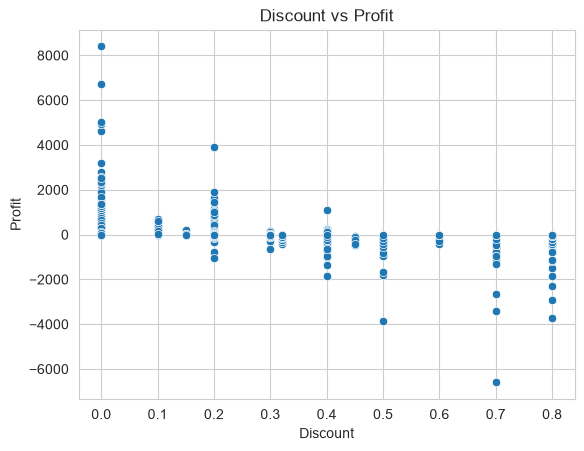

In [58]:
# Step 17 — Discount vs Profit
import seaborn as sns

sns.scatterplot(x='Discount', y='Profit', data=df)

plt.title("Discount vs Profit")
plt.show()

# ============================================
# Step 18 — Cool Visualization: Interactive Sales Map
# ============================================

We've made a bunch of static bar/line charts so far. Let's try something more
visual: an **interactive choropleth map** using `plotly`. It colors each US
state by total sales, and you can hover over a state to see the exact numbers.

New library: `plotly` (interactive charts — hover, zoom, etc., right in the notebook).

In [59]:
!pip install plotly

In [60]:
import plotly.express as px

# Map full state names -> 2-letter codes.
# Plotly's US map needs abbreviations (e.g. "California" -> "CA")
us_state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# This dataset also has Canadian provinces, so keep US rows only for the map
us_sales_by_state = (
    df[df['Country/Region'] == 'United States']
    .groupby('State/Province')[['Sales', 'Profit']]
    .sum()
    .reset_index()
)

us_sales_by_state['State Code'] = us_sales_by_state['State/Province'].map(us_state_abbrev)

fig = px.choropleth(
    us_sales_by_state,
    locations='State Code',
    locationmode='USA-states',
    color='Sales',
    scope='usa',
    color_continuous_scale='Viridis',
    hover_name='State/Province',
    hover_data={'State Code': False, 'Sales': ':$,.0f', 'Profit': ':$,.0f'},
    title='Total Sales by State'
)

fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.show()